In [ ]:
# Dependencies are managed by pyproject.toml / uv.lock for local runs.


In [11]:
import numpy as np
import pandas as pd
from umap import UMAP
import hdbscan

from sklearn.manifold import trustworthiness

In [ ]:
from pathlib import Path

import yaml

PROJECT_ROOT = Path.cwd()
with open(PROJECT_ROOT / "config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths = config["paths"]
umap_config = config["umap"]
hdbscan_config = config["hdbscan"]
random_seed = config["project"]["random_seed"]
DATA_PATH = PROJECT_ROOT / paths["bertopic_ready"]
EMBEDDING_PATH = PROJECT_ROOT / paths["embeddings"]
UMAP_PATH = PROJECT_ROOT / paths["embeddings_umap"]

In [4]:
df = pd.read_csv(DATA_PATH)

embeddings = np.load(EMBEDDING_PATH)


In [5]:
print(df.shape)

print(embeddings.shape)

(35993, 18)
(35993, 2048)


In [ ]:
assert len(df) == len(embeddings)

In [ ]:
umap_model = umap.UMAP(**umap_config["final"])

In [8]:
embeddings_umap = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [9]:
print(embeddings_umap.shape)

(35993, 5)


In [ ]:
import numpy as np
from sklearn.manifold import trustworthiness

# Fix seed for reproducibility
rng = np.random.default_rng(random_seed)

# Sample points for faster trustworthiness evaluation
sample_idx = rng.choice(
    len(embeddings),
    size=umap_config["trustworthiness"]["sample_size"],
    replace=False
)

embeddings_sample = embeddings[sample_idx]
embeddings_umap_sample = embeddings_umap[sample_idx]

score = trustworthiness(
    embeddings_sample,
    embeddings_umap_sample,
    n_neighbors=umap_config["trustworthiness"]["n_neighbors"]
)

print(score)

In [11]:
umap_vis = umap.UMAP(**umap_config["visualization"])

embeddings_2d = umap_vis.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


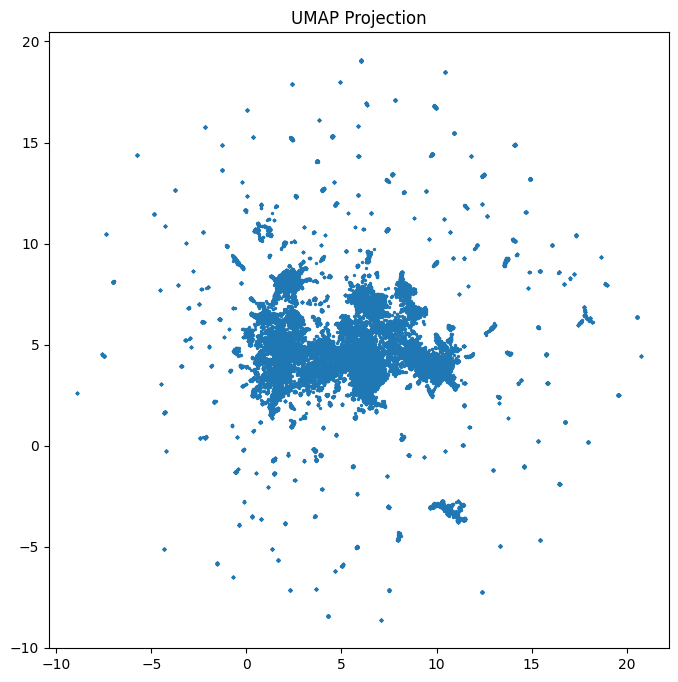

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    s=2
)

plt.title("UMAP Projection")
plt.show()

In [6]:
neighbors = umap_config["tuning"]["n_neighbors"]

min_dist = [umap_config["tuning"]["min_dist"]]

components = [umap_config["tuning"]["n_components"]]

In [12]:
# -----------------------------
# Sample for faster tuning
# -----------------------------
rng = np.random.default_rng(random_seed)

sample_idx = rng.choice(
    len(embeddings),
    size=umap_config["tuning"]["sample_size"],
    replace=False
)

emb_sample = embeddings[sample_idx]

results = []

# -----------------------------
# Tune UMAP
# -----------------------------
for n_neighbors in umap_config["tuning"]["n_neighbors"]:

    print(f"\nTesting n_neighbors = {n_neighbors}")

    reducer = UMAP(
        n_neighbors=n_neighbors,
        n_components=umap_config["tuning"]["n_components"],
        min_dist=umap_config["tuning"]["min_dist"],
        metric=umap_config["tuning"]["metric"],
        random_state=umap_config["tuning"]["random_state"]
    )

    umap_emb = reducer.fit_transform(emb_sample)

    # -----------------------------
    # Evaluate UMAP
    # -----------------------------
    trust = trustworthiness(
        emb_sample,
        umap_emb,
        n_neighbors=umap_config["tuning"]["trustworthiness_neighbors"]
    )

    # -----------------------------
    # HDBSCAN
    # -----------------------------
    clusterer = hdbscan.HDBSCAN(**hdbscan_config["umap_tuning_eval"])

    labels = clusterer.fit_predict(umap_emb)

    # -----------------------------
    # Clustering statistics
    # -----------------------------
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise_ratio = np.mean(labels == -1)

    try:
        dbcv = clusterer.relative_validity_
    except AttributeError:
        dbcv = np.nan

    results.append({
        "n_neighbors": n_neighbors,
        "trustworthiness": trust,
        "dbcv": dbcv,
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
    })

# -----------------------------
# Results
# -----------------------------
results_df = (
    pd.DataFrame(results)
      .sort_values("dbcv", ascending=False)
      .reset_index(drop=True)
)

print(results_df)


Testing n_neighbors = 10


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Testing n_neighbors = 15


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Testing n_neighbors = 30


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Testing n_neighbors = 50


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   n_neighbors  trustworthiness      dbcv  n_clusters  noise_ratio
0           15         0.957071  0.300999         142       0.3501
1           10         0.957868  0.268312         149       0.3443
2           30         0.957261  0.255301         124       0.3908
3           50         0.955363  0.195625         115       0.3981


In [13]:
# -----------------------------
# Refit best UMAP config on full data
# -----------------------------
best = results_df.iloc[0]
final_umap_params = dict(umap_config["final"])
final_umap_params["n_neighbors"] = int(best.n_neighbors)

print(
    f"Best config: n_neighbors={final_umap_params['n_neighbors']}, "
    f"n_components={final_umap_params['n_components']}, "
    f"min_dist={final_umap_params['min_dist']}"
)

reducer_final = UMAP(**final_umap_params)

embeddings_umap = reducer_final.fit_transform(embeddings)
print(embeddings_umap.shape)

np.save(UMAP_PATH, embeddings_umap)

Best config: n_neighbors=15, n_components=5, min_dist=0.0


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(35993, 5)
